# Investigating different benchmarks for TTT-discovery like optimization


## trying algo tune

In [8]:
# just a simple goal to get started. Run the tests of the reference implementations to ensure it passes everything. 
# probably locally, but if too hard, just try to get their AWS up or something.
# can get one of the submissions running from one of the models which passed.
# test the cyclic_independent_set from gpt 5.4, should have a speedup of around 680x
# they enter from the .sh or the .py in the scripts area to the AlgoTuner/main.py function, then calls llm_interface.run_task(), which does interaction loop, and 
# CommandHandlers._runner_eval_dataset gets run to get the performance of the code in the file.
# this seems to be a wrapper for evaluate_code_on_dataset, which is in utils/evaluator/main.py
# this eventually calls something called EvaluationOrchestrator.evaluate_dataset, which calls evaluate_single 
# which calls a SolverExecutor.execute, this calls isolated_benchmark.py:run_isolated_benchmark, solver.execute does timing, recording the last result for future comparison.
# THIS SEEMS TO BE THE SPOT! SolverExecutor.execute gets called by run_isolated_benchmark, this is called through the orchestrator,


# evaluate_single calls utils/evaluator/validation_pipeline:ValidationPipeline.validate, which seems to be a wrapper for the task.is_solution function. 
#       They detect solution tampering in an unexpecte way. Just checking if the main entry was overwritten with monkey patch, but this doesn't detect internal functions. 
#       They should just generate the solution first then compare the results for the generated function and the one cached before the agent's code was run.
#       ... All this shit is AI generated crap. They seem to have caught the cheating, but they fixed it by ensuring that the function didn't modify? 
#       or maybe access the safe functions, which seems like a strange work around???
# I could just code this up myself, they seem not to use the isolation containers or else the subfunctions wouldn't be messed with, so they just trust, 
# and check after the fact in the evals. I could even do better by launching a subprocess and getting the timing/data from there. Seems excessive for now, but interesting.
# The big thing is I don't know how to even test the generated code, like where do the problems get generated? -- in AlgoTuneTasks/base.py:Task.load_dataset 
# seems to load from huggingface or some json or just creates the dataset??
# they have something for downloading datasets for offline evaluation, but unsure what target_time_ms refers to? - seems default is 100, just trying this whatever. takes fucking forever wtf???

# AlgoTune/results/o4-mini/l1_pruning/solver.py try grade this.
import logging
numeric_level = getattr(logging, "INFO", None)
logging.basicConfig(level=numeric_level)


from AlgoTuner.utils.evaluator.evaluation_orchestrator import EvaluationOrchestrator
from AlgoTuner.utils.evaluator.evaluation_types import (
    CodeContext,
    DatasetResults,
    ErrorContext,
    ErrorType,
    ProblemResult,
    RunnerConfig,
)
from AlgoTuner.utils.evaluator.baseline_manager import BaselineManager
from AlgoTuner.utils.evaluator import evaluate_code_on_dataset
eo = EvaluationOrchestrator(RunnerConfig())
# evaluate_dataset(
#         self,
#         task_instance: Any,
#         dataset: list[dict[str, Any]],
#         solver_func: Callable,
#         task_name: str | None = None,
#         baseline_func: Callable | None = None,
#         progress_callback: Callable | None = None,
#         baseline_times: dict[str, float] | None = None,
#     )
from AlgoTuneTasks.factory import TaskFactory
task_l1_pruning = TaskFactory("l1_pruning")
# eo.evaluate_dataset()
# need to know either how to load dataset or how to call the thing that calls this function
# the caller is evaluate_code_on_dataset. wow, they load the function implicitly by the CODE_DIR path containing a solver.py:Solver class.
# see utils/evaluator/runner.py:run_solver_evaluation, but its unclear if this function is called inside 
#   inside evaluate_code_on_dataset, there is solver_func = getattr(task_obj, "solve", None), 
#   which seems to indicate the task object is overwritten by the LLM code??? it is still the solution object, doesn't make sense?
#   see run_oracle_evaluation in runner.py??, but who is relevant that calls this?
#   tracing from evaluate_code_on_dataset, it seems CommandHandler._runner_eval_dataset is called,
#   in one location it is explicit in saying that the solve function is loaded from CODE_DIR
#   fuck, maybe they somehow only call run_isolated_benchmark, inside runner.py:run_solver_evaluation inside evaluator/main.py:run_evaluation_on_input inside CommandHandler from _execute_eval_command inside handle_command
#       this is strange it is under "evaluate", but if you follow "eval", it is completely different and follows evaluate_code_on_dataset.
#       well, the code is evaluated when it is the "edit" command from the traces. _execute_modify_command -> _run_and_format_dataset_eval -> evaluate_code_on_dataset, 
#       but I don't fucking see where the code is loaded into the solver method??????
#       I have to run something, I'll just try to get it working whatever way I can. some example on a function from one of the saved runs. looking for high speedup not just 1.8.
#       
import os
code_dir = "/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/results/o4-mini/l1_pruning"
os.environ["CODE_DIR"] = code_dir

# train_iter, test_iter = task_l1_pruning.load_dataset()
# baseline_manager = BaselineManager(task_l1_pruning)
# os.environ["AGENT_MODE"] = "1"
# os.environ["ISOLATED_EVAL"] = "1"
#?????? these enviorn variables look at AgentCompatibleEvaluator
# eval_output = evaluate_code_on_dataset(
#     task_obj=task_l1_pruning,
#     dataset_iterable=test_iter, # using test to compare against reported results, but both should pass fully.
#     baseline_manager=baseline_manager,
#     data_subset="test",
#     default_num_eval_runs=10,
#     test_mode=True,
# )
import sys
sys.path.insert(0, "/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/scripts")
from evaluate_results import evaluate_single_task
evaluate_single_task((
    "l1_pruning",
    "bla-bla-bla", # model_name,
    "bla-bla-bla", # display_model_name,
    code_dir, # code_dir_str,
    None, # test_iter, # generation_data, unused.
    "/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/data", # data_dir_str,
    None, # num_runs, unused
))

INFO:AlgoTuner.utils.evaluator.evaluation_orchestrator:Initialized evaluation orchestrator
INFO:root:TaskFactory: Set task_instance.task_name to raw 'l1_pruning'
INFO:root:Evaluating l1_pruning for bla-bla-bla
INFO:root:TaskFactory: Mapped oracle_time_limit to target_time_ms: None
INFO:root:TaskFactory: Set task_instance.task_name to raw 'l1_pruning'
INFO:root:Created BaselineManager for l1_pruning
INFO:root:Generating baseline times for subset 'test' (attempt 1/3)
INFO:root:Using timeout multiplier 1.0x for attempt 1
INFO:root:Loading dataset for baseline generation
INFO:root:load_dataset called for task 'l1_pruning' with train_size=100, test_size=100
INFO:root:load_dataset: Determined target_time_ms via _get_target_time_ms() = 1000
/nas/ucb/jbjorner3/miniconda3/envs/algotune/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import 

📥 Downloading l1_pruning dataset from HuggingFace (oripress/AlgoTune)...
   This may take several minutes for large datasets...


INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/oripress/AlgoTune/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/oripress/AlgoTune/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSmtZWFJoTDJGeWRHbGpkV3hoZEdsdmJsOXdiMmx1ZEhNdlgyNXdlVjlrWVhSaEx6WmhZekF5WVRNNExURmlaVGt0TkRReVppMDVZV0ppTFRRek16QTNNV1EyTlRBMVpTNXVjSGtpTENKMGNtVmxYMjlwWkNJNklqRm1Zakl4TUdFeVptSTRaR05sTVRRNE1qbGxZMkpqWTJJeU16azRZVFEwWlRCalpqY3pNemdpZlE9PToxMDAw "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/oripress/AlgoTune/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSmtZWFJoTDJOb2IyeGxjMnQ1WDJaaFkzUnZjbWw2WVhScGIyNHZYMjV3ZVY5a1lYUmhMell6WVRjNE5UTmxMVFV5TWpndE5HSmpNeTFpT0RCa0xUSmxPVGcwTUdGa1pUWmlOUzV1Y0hraUxDSjBjbVZsWDI5cFpDSTZJakZtWWpJeE1HRXlabUk0WkdObE1UUTRNamxsWTJKalkySXlNems0WVRRMFpUQmpaamN6TXpnaWZRPT06MjAwMA%3D%3D "HTTP/1.1 200 O

✓ Download complete! Dataset cached at /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/.hf_datasets/oripress__AlgoTune


Attempting to load config from: /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/AlgoTuner/config/config.yaml
Successfully loaded config from: /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/AlgoTuner/config/config.yaml
INFO:AlgoTuner.utils.isolated_benchmark:[TIMEOUT_DEBUG_ISO] Waiting for subprocess with timeout=60.000s
INFO:root:DIAG: extract_error_context called with error_msg: ...
INFO:root:DIAG: Cleaned traceback (first 100 chars): BdbQuit: 
Traceback (most recent call last):
  File "./utils/isolated_benchmark.py", line 551, in _f...
INFO:root:DIAG: Found 13 lines in traceback
INFO:root:DIAG: Last line of traceback: bdb.BdbQuit
INFO:root:DIAG: Last line of traceback ('bdb.BdbQuit') does not appear to be a standard exception message. Not attempting to refine error message.
INFO:root:DIAG: Found error in file: ~/miniconda3/envs/algotune/lib/python3.10/bdb.py, line: 115
INFO:root:DIAG: Found error in file: ~/miniconda3/envs/algotune/lib/python3.10/bdb.

...

> /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/AlgoTuner/utils/solver_loader.py(264)load_solver_module()
    263 
--> 264     import tempfile
    265     import uuid

ipdb> 


Attempting to load config from: /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/AlgoTuner/config/config.yaml
Successfully loaded config from: /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/AlgoTuner/config/config.yaml
INFO:AlgoTuner.utils.isolated_benchmark:[TIMEOUT_DEBUG_ISO] Waiting for subprocess with timeout=60.000s
INFO:root:DIAG: extract_error_context called with error_msg: ...
INFO:root:DIAG: Cleaned traceback (first 100 chars): BdbQuit: 
Traceback (most recent call last):
  File "./utils/isolated_benchmark.py", line 551, in _f...
INFO:root:DIAG: Found 13 lines in traceback
INFO:root:DIAG: Last line of traceback: bdb.BdbQuit
INFO:root:DIAG: Last line of traceback ('bdb.BdbQuit') does not appear to be a standard exception message. Not attempting to refine error message.
INFO:root:DIAG: Found error in file: ~/miniconda3/envs/algotune/lib/python3.10/bdb.py, line: 115
INFO:root:DIAG: Found error in file: ~/miniconda3/envs/algotune/lib/python3.10/bdb.

> /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/AlgoTuner/utils/solver_loader.py(264)load_solver_module()
    263 
--> 264     import tempfile
    265     import uuid

ipdb> 


Attempting to load config from: /nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/AlgoTuner/config/config.yaml


KeyboardInterrupt: 

In [2]:
from AlgoTuner.utils.solver_loader import load_solver_module

In [2]:
from AlgoTuner.utils.solver_loader import load_solver_module, with_working_dir

code_dir = "/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/AlgoTune/results/o4-mini/l1_pruning" #/solver.py"
with with_working_dir(code_dir):
    solver_module = load_solver_module(code_dir)


In [12]:
import inspect
print(inspect.getsource(solver_module.Solver().solve))

    def solve(self, problem, **kwargs):
        v = np.asarray(problem["v"], dtype=np.float64)
        k = float(problem["k"])
        w = _proj_l1_numba(v, k)
        return {"solution": w}



In [15]:
eval_output

[{'problem_id': '142',
  'success': True,
  'is_valid': True,
  'timeout_occurred': False,
  'min_time_ms': 149.723431,
  'mean_ms': 153.0682268,
  'values_ms': [153.884883,
   150.083016,
   149.723431,
   154.546584,
   155.575592,
   153.871132,
   153.290439,
   152.40773,
   152.918734,
   154.380727],
  'elapsed_ms': 1530.682268,
  'validation_result': {'success': True, 'error_type': 'none', 'error': None},
  'speedup': 1.9675692911418787,
  'baseline_time_ms': 294.591225,
  'solver_min_time_ms': 149.723431},
 {'problem_id': '143',
  'success': True,
  'is_valid': True,
  'timeout_occurred': False,
  'min_time_ms': 92.989268,
  'mean_ms': 95.6238164,
  'values_ms': [96.617924,
   92.989268,
   93.255844,
   93.857547,
   93.746049,
   95.950332,
   97.612073,
   97.02926,
   97.362006,
   97.817861],
  'elapsed_ms': 956.238164,
  'validation_result': {'success': True, 'error_type': 'none', 'error': None},
  'speedup': 2.564404163284735,
  'baseline_time_ms': 238.462066,
  'solver

In [5]:
eval_output

[{'problem_id': '142',
  'success': True,
  'is_valid': True,
  'timeout_occurred': False,
  'min_time_ms': 147.566431,
  'mean_ms': 155.0181426,
  'values_ms': [147.566431,
   172.560802,
   154.670128,
   154.212304,
   155.42265,
   153.966076,
   153.198236,
   153.61866,
   152.712602,
   152.253537],
  'elapsed_ms': 1550.181426,
  'validation_result': {'success': True, 'error_type': 'none', 'error': None},
  'speedup': 1.9813844857439156,
  'baseline_time_ms': 292.385837,
  'solver_min_time_ms': 147.566431},
 {'problem_id': '143',
  'success': True,
  'is_valid': True,
  'timeout_occurred': False,
  'min_time_ms': 92.627257,
  'mean_ms': 96.97380969999999,
  'values_ms': [92.627257,
   93.320419,
   97.55199,
   97.513011,
   98.137433,
   101.83255,
   97.357753,
   97.197014,
   97.283772,
   96.916898],
  'elapsed_ms': 969.7380969999999,
  'validation_result': {'success': True, 'error_type': 'none', 'error': None},
  'speedup': 2.5579483369565827,
  'baseline_time_ms': 236.935

In [ ]:
# fun question, how much extra do these model providers charge?
# determine this from prefill/ training prices
# the prefill should be 1/2 the training price, but the reality is training is more than double prefill, I'll determine the profit margin for both
# assume the real pricing is h100 hour specific at 2$ / 1 h100 hour, and you hit 1 petaflop bfloat16, and assume 50-80% mfu for prefill?
# they charge 0.13 $ per 10**6 tokens of prefill, 0.4 for training
# thats 10**6 * 8 * 10 ** 9 * 2 flops 
# you have available, per second, how many seconds do you need to process that 0.5 * 10 ** 15 to 0.8 * 10 ** 15
# lower end (10**6 * 8 * 10 ** 9 * 2) / (0.8 * 10 ** 15) = 20, upper is 32
# 30 seconds, is 30/3600 of an hour which is less than 1%, so should be less than 0.02 $ for prefill, but I guess some inefficiency in the system waiting around for use, and 
# they make roughly 8-12 x margin, which is nice. could be much lower depending on compute fraction spent on attention.

In [ ]:
from dotenv import load_dotenv
import asyncio
from openai import AsyncOpenAI
import os
import torch
import datasets
# import nest_asyncio
# nest_asyncio.apply()

from pprint import pprint
load_dotenv()

True

In [22]:
client = AsyncOpenAI(base_url="https://openrouter.ai/api/v1",
                     api_key=os.environ['OPENROUTER_API_KEY'])
ret = await (client.chat.completions.create(messages=[{'role': "user", "content": "hello there!"}],
                                           model="qwen/qwen3-8b"))

In [23]:
pprint(ret.model_dump())

{'choices': [{'finish_reason': 'stop',
              'index': 0,
              'logprobs': None,
              'message': {'annotations': None,
                          'audio': None,
                          'content': 'Hello! 😊 How can I assist you today? Let '
                                     'me know if you have any questions or '
                                     'need help with something!',
                          'function_call': None,
                          'reasoning': 'Okay, the user said "hello there!" so '
                                       'I need to respond appropriately. Let '
                                       'me start by acknowledging their '
                                       'greeting. Maybe say something like '
                                       '"Hello!" to be friendly. Then, I '
                                       'should ask how I can assist them. '
                                       'Since they might have a question or '
   

np.float64(1.538943938852415)

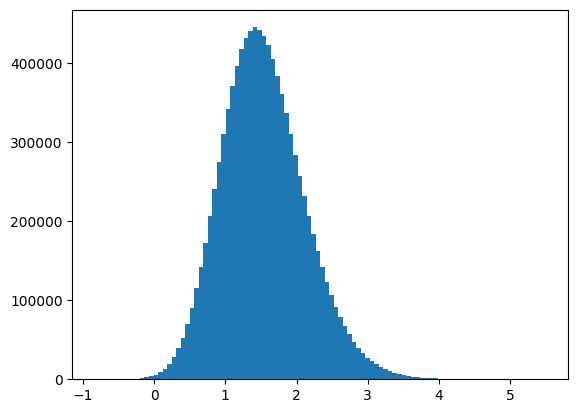

In [73]:
import numpy as np
import matplotlib.pyplot as plt
# want pmf on max over 100 samples from a gaussian 10000 times
data = np.random.randn(10000000*10).reshape(10000000,10)
plt.hist(data.max(-1), bins=100);
data.max(-1).mean()

In [83]:
import scipy 
scipy.stats.Normal().cdf(0.967)#1.825) # 0.965)

np.float64(0.8332279831682811)

In [ ]:
fraction_of_BoN_improved = (0.8332)**10 # 1-x^(n-1) = x find x for some n? find roots of -x^(n-1) - x + 1 polynomial. monomial, might have some special roots. we only care about its root on [0,1], on which it is negative first derivative, so must only have one root. 
# 0.19352779636616965
fraction_of_BoN_made_worse = (1-0.8332) * (0.8332)**9 # this is where the change to an 83'rd percentile number made the BoN worse.
# looking for the probability that the BoN is made worse, so I need the probability that the first one was the highest number, and the rest of the numbers were anything, but no higher than the first.
# ???? probably don't need to think about this actually, then I can just stop and go back to reasoning about the Q and V on my notes.Perhaps pass @ k math for this is easier, which is why its presented in Andrea Zannett's paper.
fraction_of_BoN_made_worse
# 0.03228043643387709

0.03228043643387709

In [110]:
data[17], new_data[17]

(array([ 2.1467153 , -0.79291985,  0.25121332,  0.75795788,  0.35764038,
        -1.21358173, -0.96970527,  1.10675357, -0.31509593, -0.94515311]),
 array([ 0.967     , -0.79291985,  0.25121332,  0.75795788,  0.35764038,
        -1.21358173, -0.96970527,  1.10675357, -0.31509593, -0.94515311]))

In [111]:
(new_data.max(-1) < data.max(-1)).mean()

np.float64(0.083945)

(np.float64(1.5388540117657992), np.float64(0.1935102))

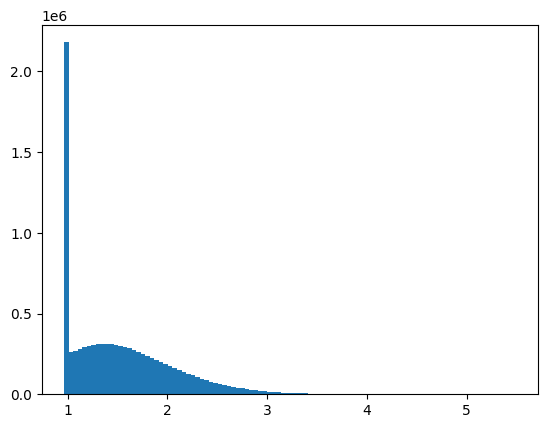

In [82]:
new_data = np.concat([data[:,[0]] * 0 + 0.967, data[:,1:]], axis=1) 
# for 10 samples in BoN you need to be better than 83% of samples to shift the expected boN upwards
# for 100 samples in BoN you need to be better than 96% of samples to shift the expected boN upwards
plt.hist(new_data.max(-1), bins=100);
new_data.max(-1).mean(), (new_data.max(-1) == new_data.max(-1).min()).mean()
